# Evaluación Primer Bimestre
---
- **Nombre**: Michael Enríquez
- **Fecha**: 13 de mayo, 2026
---
## Objetivo de la práctica
El objetivo de este examen es evaluar la capacidad de los estudiantes para desarrollar un Sistema de 
Recuperación de Información capaz de indexar un corpus de documentos textuales mediante embeddings y 
recuperar los documentos más relevantes para una consulta utilizando similitud coseno. 

## Parte 0: Carga del Corpus

Vamos a utilizar la API de Kaggle para acceder al dataset

El corpus está disponible desde este [link](https://www.kaggle.com/datasets/stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset)

#### Actividad

1. Carga el corpus


In [18]:
import os
import pandas as pd
import kagglehub

# Descargar dataset
path = kagglehub.dataset_download(
    'stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset'
)

# Cargar datos
reviews = pd.read_csv(
    os.path.join(path, 'rotten_tomatoes_critic_reviews.csv')
)

movies = pd.read_csv(
    os.path.join(path, 'rotten_tomatoes_movies.csv')
)

# Unir datasets y filtrar reviews vacías
df = (
    reviews
    .merge(
        movies[['rotten_tomatoes_link', 'movie_title']],
        on='rotten_tomatoes_link',
        how='left'
    )
    .dropna(subset=['review_content'])
    .reset_index(drop=True)
)

# Crear identificadores
df['doc_id'] = [f'doc_{i}' for i in range(len(df))]

# Documento textual
df['document'] = (
    df['movie_title'].fillna('') + ' ' +
    df['review_content'].fillna('')
)

# Validación
print(df[['doc_id', 'movie_title', 'document']].head())
print('\nShape:', df.shape)

  doc_id                                        movie_title  \
0  doc_0  Percy Jackson & the Olympians: The Lightning T...   
1  doc_1  Percy Jackson & the Olympians: The Lightning T...   
2  doc_2  Percy Jackson & the Olympians: The Lightning T...   
3  doc_3  Percy Jackson & the Olympians: The Lightning T...   
4  doc_4  Percy Jackson & the Olympians: The Lightning T...   

                                            document  
0  Percy Jackson & the Olympians: The Lightning T...  
1  Percy Jackson & the Olympians: The Lightning T...  
2  Percy Jackson & the Olympians: The Lightning T...  
3  Percy Jackson & the Olympians: The Lightning T...  
4  Percy Jackson & the Olympians: The Lightning T...  

Shape: (1064211, 11)


## Parte 1: Preprocesamiento Del Corpus

In [19]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    # Eliminar puntuación
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Eliminar espacios redundantes
    text = re.sub(r'\s+', ' ', text).strip()
    # Eliminar stopwords
    text = ' '.join(
        word for word in text.split()
        if word not in stop_words
    )
    return text

df['prep'] = df['document'].apply(preprocess)
print(df['prep'].iloc[0][:200])

percy jackson olympians lightning thief fantasy adventure fuses greek mythology contemporary american places values anyone around 15 give take couple years thrill visual spectacle


## Parte 2: Generación de Embeddings

In [26]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Opcional: reducir corpus
df = df.sample(5000, random_state=42).reset_index(drop=True)

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(
    df['prep'].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True
)

np.save('embeddings.npy', embeddings)
print("Embeddings:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Embeddings: (5000, 384)


## Parte 3: Búsqueda por Similitud Coseno

In [29]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def buscar_documentos(query, k=10):

    # Preprocesar consulta
    query = preprocess(query)

    # Embedding consulta
    query_embedding = model.encode(
        [query],
        normalize_embeddings=True
    )

    # Similitud coseno
    similarities = cosine_similarity(
        query_embedding,
        embeddings
    )[0]

    # Top-k documentos
    top_indices = similarities.argsort()[::-1][:k]

    # Resultados
    results = []

    for rank, idx in enumerate(top_indices, start=1):

        results.append({
            'Ranking': rank,
            'ID': df.iloc[idx]['doc_id'],
            'Título': df.iloc[idx]['movie_title'],
            'Fragmento': df.iloc[idx]['review_content'][:150],
            'Similitud': round(similarities[idx], 4)
        })

    return pd.DataFrame(results)

# Test de búsqueda
query = "science fiction movie with advanced technology"
results = buscar_documentos(query, k=10)
print(results)

   Ranking           ID                          Título  \
0        1   doc_990707  Transformers: Dark of the Moon   
1        2   doc_549101                            Moon   
2        3  doc_1009645                         Upgrade   
3        4   doc_294791                         Elysium   
4        5   doc_205248      Captain America: Civil War   
5        6   doc_370871                       Hall Pass   
6        7   doc_811223                Star Trek Beyond   
7        8  doc_1025260               War of the Worlds   
8        9   doc_330830                        Fracture   
9       10   doc_101964                     After Earth   

                                           Fragmento  Similitud  
0  These Transformer movies are nonsense, of cour...     0.5192  
1  This excellent little science fiction film is ...     0.5149  
2  Upgrade is a future-shock action horror film s...     0.4833  
3  This is a big budget science fiction film with...     0.4831  
4  A non-stop action

## Parte 4: Ejecución de Consultas Benchmark

In [30]:
# Consultas benchmark
queries = {
    'Q1': 'science fiction movie with advanced technology',
    'Q2': 'romantic story with emotional relationships',
    'Q3': 'action movie with intense fight scenes',
    'Q4': 'horror film that creates fear and suspense',
    'Q5': 'visually impressive movie with weak storyline',
    'Q6': 'emotionally moving performance by the lead actor',
    'Q7': 'predictable plot but entertaining experience',
    'Q8': 'movie praised by critics but unpopular with audiences'
}

# Ejecutar búsquedas
results_by_query = {
    q_id: buscar_documentos(query, k=10)
    for q_id, query in queries.items()
}

print("Consultas benchmark ejecutadas")

Consultas benchmark ejecutadas


In [31]:
from IPython.display import display

for q_id, query in queries.items():
    print(f'\n{q_id}: {query}')
    display(results_by_query[q_id])



Q1: science fiction movie with advanced technology


,Ranking,ID,Título,Fragmento,Similitud
0,1,doc_990707,Transformers: Dark of the Moon,"These Transformer movies are nonsense, of cour...",0.5192
1,2,doc_549101,Moon,This excellent little science fiction film is ...,0.5149
2,3,doc_1009645,Upgrade,Upgrade is a future-shock action horror film s...,0.4833
3,4,doc_294791,Elysium,This is a big budget science fiction film with...,0.4831
4,5,doc_205248,Captain America: Civil War,"A non-stop action movie, but they can't stop t...",0.4755
5,6,doc_370871,Hall Pass,Let's just say Indiana Jones riding out a nucl...,0.4695
6,7,doc_811223,Star Trek Beyond,Michael Bay has won. Every movie has now becom...,0.4596
7,8,doc_1025260,War of the Worlds,great flick from spielberg,0.4544
8,9,doc_330830,Fracture,The central mystery is a tidy piece of prestid...,0.4514
9,10,doc_101964,After Earth,This is one of those movies where you suspect ...,0.4508



Q2: romantic story with emotional relationships


,Ranking,ID,Título,Fragmento,Similitud
0,1,doc_503575,Love Story,Although the relationship between Oliver and J...,0.5417
1,2,doc_213438,Celeste and Jesse Forever,This romantic comedy is ambitious and thoughtf...,0.5195
2,3,doc_501883,Love at First Fight,"Even when it's slowing down, Fight shows begui...",0.5024
3,4,doc_829675,The Story of Us,"According to The Story of Us, men and women ha...",0.5014
4,5,doc_1026072,Warm Bodies,To call this an unlikely love story is an unde...,0.5009
5,6,doc_544483,Modern Life Is Rubbish,Exploring a relationship by flicking between b...,0.4892
6,7,doc_314327,The Father of My Children (Le pere de mes enfa...,"Father is a very intimate film, and writer-dir...",0.4887
7,8,doc_407271,I Give It a Year,Turns the romantic comedy on its head by utili...,0.4823
8,9,doc_659032,Red 2,RED 2 is perilously close to a formulaic roman...,0.4818
9,10,doc_632420,Professor Marston & The Wonder Women,"What's so surprising is how [Angela] Robinson,...",0.4805



Q3: action movie with intense fight scenes


...

,Ranking,ID,Título,Fragmento,Similitud
0,1,doc_938079,The New Romantic,Clever writing and a solid lead actor will onl...,0.5401
1,2,doc_941540,The Other Son,"A provocative, moving social drama, superbly t...",0.5176
2,3,doc_424438,The Insider,It's the Oscar-caliber performances that comma...,0.5083
3,4,doc_914685,The Ides of March,"Without anyone noticing, George Clooney has be...",0.5075
4,5,doc_890212,The End of Love,Webber appears to be making an audition tape w...,0.4999
5,6,doc_501153,Love Actually,Whatever the actors are given to do they make ...,0.4991
6,7,doc_735417,Sex Drive,Given the absence of any real freshness or ins...,0.4911
7,8,doc_14137,Frozen,"McKoen shows an evocative, emotional style wit...",0.4805
8,9,doc_851258,Take the Lead,This handsomely lighted movie has the craft to...,0.4689
9,10,doc_244640,Creep 2,It should be harder to sell this character wit...,0.4682



Q7: predictable plot but entertaining experience


,Ranking,ID,Título,Fragmento,Similitud
0,1,doc_1012709,Valiant,A disarmingly enjoyable movie with a lively ca...,0.5513
1,2,doc_257699,Dead Man Down,A pleasingly intricate double (or is it triple...,0.5418
2,3,doc_493228,Live By Night,"Man, that plot. You really can't pick where th...",0.5244
3,4,doc_559115,Mutant Chronicles,"Mutant Chronicles has an intriguing premise, g...",0.5169
4,5,doc_142986,Back to the Future Part II,Solidly entertaining.,0.5124
5,6,doc_13123,Chloe,"It has a starry cast, a twisty plot that clear...",0.5063
6,7,doc_220688,Child's Play,If the plotting and character beats are a tad ...,0.5060
7,8,doc_761705,Sinbad: Legend of the Seven Seas,"The effects are competent, the action has exci...",0.5046
8,9,doc_722227,Searching,That a thriller would come along utilizing the...,0.5016
9,10,doc_934169,The Maze Runner,The Maze Runner is a slickly plot-driven flick...,0.4977



Q8: movie praised by critics but unpopular with audiences


,Ranking,ID,Título,Fragmento,Similitud
0,1,doc_9039,The Promotion,"I predict that when this film is released, lot...",0.5990
1,2,doc_753451,Shut In,Shut In is a very bad movie anchored by a very...,0.5489
2,3,doc_377022,Harry Potter and the Deathly Hallows - Part 2,"If ever there was a critic-proof film, this is...",0.5373
3,4,doc_432464,It,It is a horror movie that should delight fans ...,0.5232
4,5,doc_690231,Rollerball,A movie of such rank stupidity and appalling t...,0.5111
5,6,doc_887443,The Disappointments Room,Disappointments has the strange confidence of ...,0.5081
6,7,doc_781176,Solo: A Star Wars Story,This is franchise film-making at its worst.,0.4957
7,8,doc_418973,Incendies,"It is the very fact that the hatred is blind, ...",0.4908
8,9,doc_871566,The Best of Enemies,"This movie isn't just tone-deaf, it's ass back...",0.4848
9,10,doc_37139,10 Cloverfield Lane,"With or without the Cloverfield business, 10 C...",0.4815


## Parte 5: Tabla Resumen General

In [33]:
resumen_df = pd.DataFrame([
    {
        'Consulta': q_id,
        'Texto Consulta': query,
        'Documento Top-1': results_by_query[q_id].iloc[0]['ID'],
        'Título Película': results_by_query[q_id].iloc[0]['Título'],
        'Similitud': results_by_query[q_id].iloc[0]['Similitud']
    }

    for q_id, query in queries.items()
])

print("Tabla Resumen General")
display(resumen_df)

Tabla Resumen General


,Consulta,Texto Consulta,Documento Top-1,Título Película,Similitud
0,Q1,science fiction movie with advanced technology,doc_990707,Transformers: Dark of the Moon,0.5192
1,Q2,romantic story with emotional relationships,doc_503575,Love Story,0.5417
2,Q3,action movie with intense fight scenes,doc_187855,Brawl in Cell Block 99,0.5996
3,Q4,horror film that creates fear and suspense,doc_21553,Night of the Living Dead,0.6813
4,Q5,visually impressive movie with weak storyline,doc_699819,Running From Crazy,0.6240
5,Q6,emotionally moving performance by the lead actor,doc_938079,The New Romantic,0.5401
6,Q7,predictable plot but entertaining experience,doc_1012709,Valiant,0.5513
7,Q8,movie praised by critics but unpopular with au...,doc_9039,The Promotion,0.5990


## Valor Agregado: Visualización de embeddings con PCA

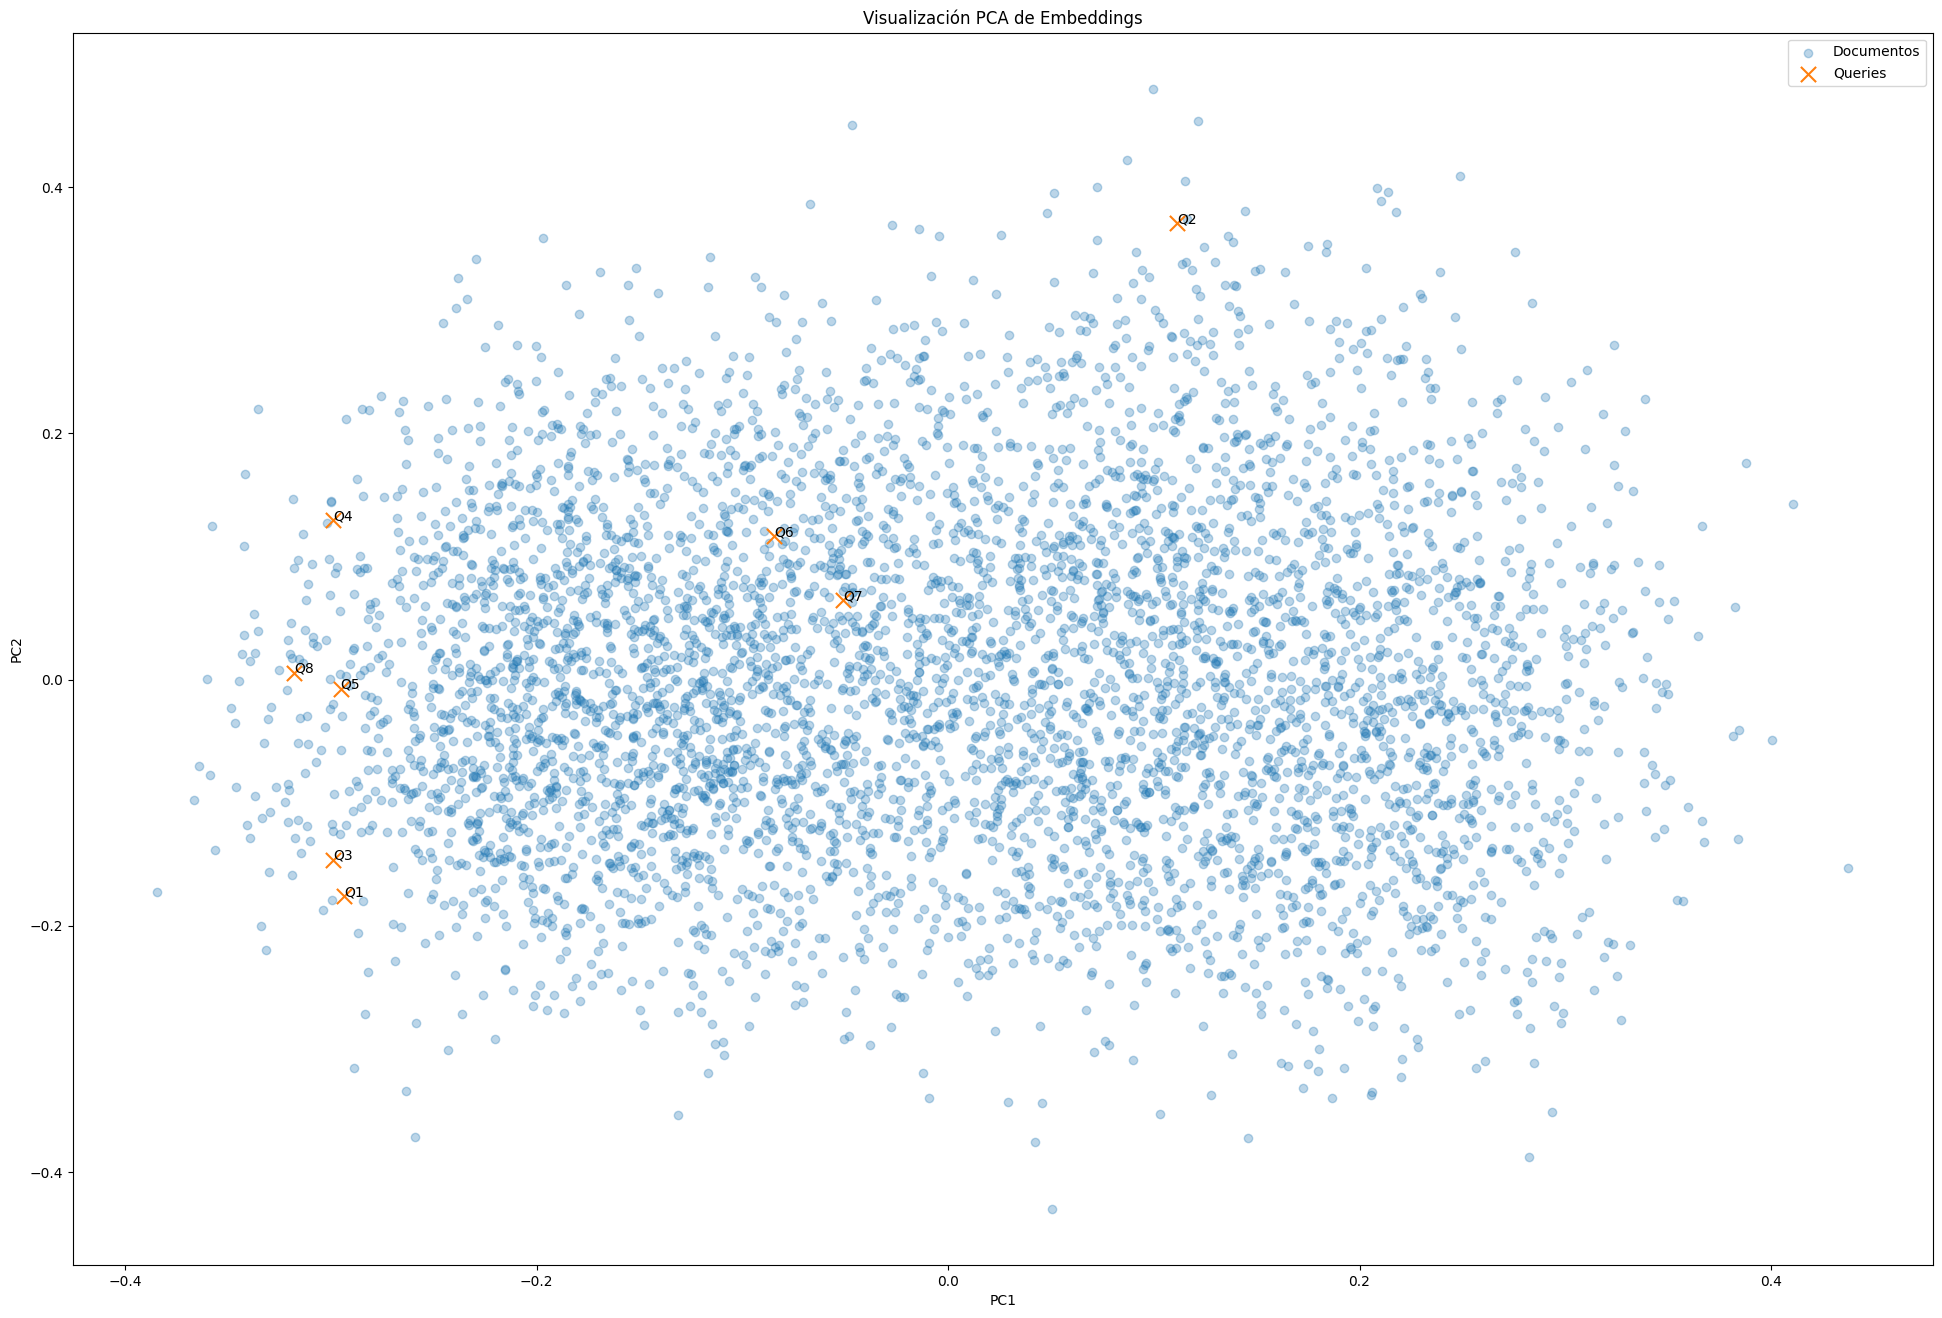

In [39]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Embeddings de queries
query_texts = list(queries.values())

query_embeddings = model.encode(
    query_texts,
    normalize_embeddings=True
)

# Combinar embeddings
all_embeddings = np.vstack([embeddings, query_embeddings])

# PCA
pca = PCA(n_components=2)

all_2d = pca.fit_transform(all_embeddings)

# Separar documentos y queries
doc_2d = all_2d[:len(embeddings)]
query_2d = all_2d[len(embeddings):]

# Plot
plt.figure(figsize=(24, 16))

# Documentos
plt.scatter(
    doc_2d[:, 0],
    doc_2d[:, 1],
    alpha=0.3,
    label='Documentos'
)

# Queries
plt.scatter(
    query_2d[:, 0],
    query_2d[:, 1],
    s=120,
    marker='x',
    label='Queries'
)

# Etiquetas queries
for i, q_id in enumerate(queries.keys()):

    plt.text(
        query_2d[i, 0],
        query_2d[i, 1],
        q_id,
        fontsize=10
    )

plt.title('Visualización PCA de Embeddings')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.legend()

plt.show()